# Simple Linear Regression

### 1. The Statsmodels Approach

**Focus**: Inference, Significance, and Causality.

- In this version, you care about the relationship itself. You want to know if lstat is a "real" driver of price and how much weight it carries.

**Primary Research Question:**

- *To what extent is there a statistically significant relationship between neighborhood socioeconomic status (`lstat`) and median home values (`medv`), and what is the specific magnitude of that effect?*

In [8]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [9]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [10]:
bs = pd.read_csv("Boston.csv")
display(bs.head(10))
display(bs.shape)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,17.10,18.9


(506, 13)

In [16]:
X = pd.DataFrame({'intercept': np.ones(bs.shape[0]),
'lstat': bs['lstat']})
X.head()

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94
4,1.0,5.33


In [20]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
intercept,506.0,1.000000,0.000000,1.00,1.00,1.00,1.000,1.00
lstat,506.0,12.653063,7.141062,1.73,6.95,11.36,16.955,37.97


In [17]:
y = bs['medv']
model = sm.OLS(y, X)
results = model.fit()

In [18]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           5.08e-88
Time:                        18:01:05   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

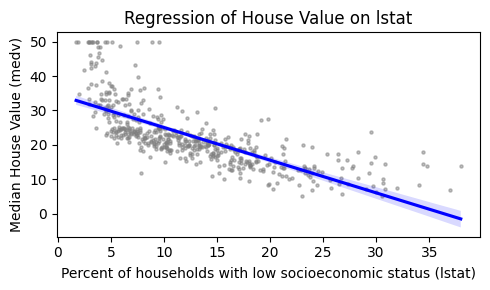

In [24]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.regplot(x='lstat', y='medv', data=bs, 
            scatter_kws={'color': 'gray', 's': 5, 'alpha': 0.5}, 
            line_kws={'color': 'blue'})

ax.set_title('Regression of House Value on lstat')
ax.set_xlabel('Percent of households with low socioeconomic status (lstat)')
ax.set_ylabel('Median House Value (medv)')

plt.tight_layout()
plt.show()

### 2. The Scikit-Learn Approach: "The Predictor"

**Focus:** Accuracy, Generalization, and Performance.

- In this version, you don't actually care why the relationship exists as much as you care about how well you can guess the price of a house you’ve never seen before.

**Primary Research Question:**

- *Can a linear model trained on socioeconomic data (lstat) accurately generalize to unseen neighborhoods to predict median home values within a tolerable margin of error?*

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [26]:
# 1. Define X and y (Simple version, no manual intercept needed)
X = bs[['lstat']] 
y = bs['medv']

# 2. Split the data
# We keep 20% of the data in a "vault" to test the model later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make Predictions
# We predict on the 'Test' set (data the model has NEVER seen)
y_pred = model.predict(X_test)

In [29]:
# How far off are our predictions on average?
mse = mean_squared_error(y_test, y_pred)
# How much of the 'Test' data variance did we capture?
r2 = r2_score(y_test, y_pred)
# Error in actual dollar units
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(33.52) # Square root of your MSE

print(f"MAE: {mae:.2f} ($1000s)")
print(f"RMSE: {rmse:.2f} ($1000s)")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

MAE: 4.18 ($1000s)
RMSE: 5.79 ($1000s)
Mean Squared Error: 33.52
R-squared Score: 0.54


In [30]:
# Create a comparison table
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Add a column for the specific error (Residual)
comparison_df['Error'] = comparison_df['Actual'] - comparison_df['Predicted']

display(comparison_df.head(10))

,Actual,Predicted,Error
173,23.6,26.099510,-2.499510
274,32.4,31.425096,0.974904
491,13.6,17.371736,-3.771736
72,22.8,29.501699,-6.701699
452,16.1,18.144961,-2.044961
76,20.0,23.267575,-3.267575
316,17.8,17.120438,0.679562
140,14.0,11.485563,2.514437
471,19.6,22.397697,-2.797697
500,16.8,20.986562,-4.186562


#### The "Identity Plot" 

Instead of a scatter plot with a line, the gold standard for evaluating predictions is an Actual vs. Predicted Plot.If your model was perfect, every dot would fall on a $45^\circ$ diagonal line. Dots far away from that line are your "failures."

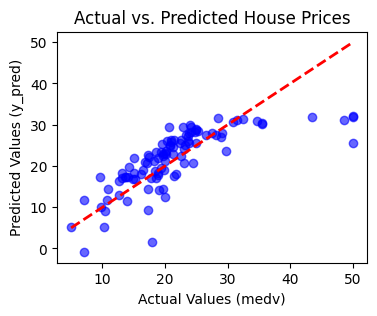

In [35]:
plt.figure(figsize=(4, 3))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')

# Draw the 'Perfect Prediction' line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Values (medv)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted House Prices')
plt.show()

#### The Residual Plot (The "Health Check")

This graph plots your Errors on the Y-axis.
- **Goal:** The dots should look like a random "cloud" around the zero line.
- **Warning:** If you see a "U-shape" or a "Funnel-shape," it means your linear model is missing a non-linear pattern in the data (e.g., house prices might drop faster than a straight line allows).

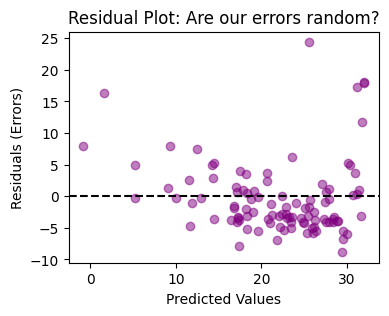

In [37]:
residuals = y_test - y_pred
plt.figure(figsize=(4, 3))
plt.scatter(y_pred, residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot: Are our errors random?')
plt.show()

### 3. Annex - OLS Regression Output

#### Model Structure

- **Dependent Variable (Dep. Variable)**  
  The response variable $Y$ being modeled.  
  Formally, we estimate the conditional expectation $\mathbb{E}[Y \mid X]$.

- **Model (OLS)**  
  Ordinary Least Squares estimator. It chooses coefficients $\hat{\beta}$ to minimize:
  $$
  \sum_{i=1}^n (y_i - \hat{y}_i)^2
  $$

- **Number of Observations (No. Observations)**  
  The sample size $n$, i.e., number of data points.

- **Degrees of Freedom (Df Model)**  
  Number of explanatory variables (excluding the intercept).

- **Degrees of Freedom (Df Residuals)**  
  Remaining degrees of freedom after estimation:
  $$
  n - p
  $$
  where $p$ is the number of estimated parameters (including intercept).

#### Goodness of Fit

- **R-squared ($R^2$)**  
  Proportion of variance in $Y$ explained by the model:
  $$
  R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}
  $$

- **Adjusted R-squared**  
  Penalized version of $R^2$:
  $$
  \bar{R}^2 = 1 - \frac{\text{RSS}/(n-p)}{\text{TSS}/(n-1)}
  $$
  Adjusts for the number of predictors.

#### Global Model Significance

- **F-statistic**  
    → Measures whether your model explains significantly more variance than a model with no predictors.   
  Tests the null hypothesis:
  $$
  H_0: \beta_1 = \beta_2 = \cdots = \beta_k = 0
  $$

- **Prob (F-statistic)**  
  p-value associated with the F-test.

#### Coefficients

- **Coefficient (coef)**  
  Estimated parameter $\hat{\beta}_j$. Represents the marginal effect:
  $$
  \frac{\partial \mathbb{E}[Y \mid X]}{\partial X_j}
  $$

- **Intercept**  
  Expected value of $Y$ when all predictors are zero.  
  → Not always meaningful in reality, but anchors the regression line.

#### Estimation Uncertainty

- **Standard Error (std err)**  
    → Measures uncertainty in coefficient estimates.
  Standard deviation of the estimator:
  $$
  \sqrt{\mathrm{Var}(\hat{\beta}_j)}
  $$

- **t-statistic (t)**  
  Test statistic for:
  $$
  H_0: \beta_j = 0
  $$
  Defined as:
  $$
  t = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)}
  $$
  → Ratio: (coefficient ÷ standard error).   
  → Larger magnitude = stronger evidence the coefficient ≠ 0.   

- **p-value (P>|t|)**  
  Probability of observing such a t-statistic under $H_0$.   

- **Confidence Interval ([0.025, 0.975])**   
    → Range where the true coefficient likely lies (95% confidence).
  Interval estimate:
  $$
  \hat{\beta}_j \pm t_{0.975} \cdot \text{SE}(\hat{\beta}_j)
  $$

#### Likelihood-Based Metrics

- **Log-Likelihood**  
  → Measures how well the model fits the data (higher is better).   
  → Mainly used for comparing models.
  Logarithm of the likelihood function:
  $$
  \log L(\hat{\beta}, \hat{\sigma}^2)
  $$

- **AIC (Akaike Information Criterion)**   
    → Balances fit vs complexity.   
    → Lower = better model (when comparing alternatives).
  $$
  \text{AIC} = 2p - 2\log L
  $$

- **BIC (Bayesian Information Criterion)**  
    → Similar to AIC, but penalizes complexity more heavily.   
    → Useful for model selection.
  $$
  \text{BIC} = p \log n - 2\log L
  $$


#### Residual Diagnostics

- **Durbin–Watson Statistic**  
  Tests for autocorrelation in residuals:
  $$
  DW \approx 2(1 - \hat{\rho})
  $$

#### Normality Tests

- **Omnibus Test**  
  Joint test for skewness and kurtosis deviations from normality.   
  → Tests whether residuals are normally distributed.

- **Jarque–Bera (JB)**  
  Tests normality using:
  $$
  JB \propto (\text{skewness}^2 + (\text{kurtosis} - 3)^2)
  $$

- **Prob (Omnibus), Prob (JB)**  
  Corresponding p-values.

- **Skew**  
  Measures asymmetry (third standardized moment).

- **Kurtosis**  
  Measures tail heaviness (fourth standardized moment).

#### Numerical Stability

- **Condition Number (Cond. No.)**  
  Measures numerical sensitivity:
  $$
  \kappa(X) = \frac{\sigma_{\max}}{\sigma_{\min}}
  $$
  High values indicate multicollinearity or scaling issues.

#### Conceptual Summary

- **Fit quality** → $R^2$, Adjusted $R^2$  
- **Inference on parameters** → coefficients, SE, t, p-values, CI  
- **Model comparison** → Log-Likelihood, AIC, BIC  
- **Assumption diagnostics** → normality tests, autocorrelation, condition number  